# CS-616 Term Project - Optimization Algorithms (Semester 2, AY 2025/2026)

## Advanced AI Copy: Data-Driven SOC Alert Triage Scheduling in a Shift

- **Student Name:** Yasir Alharbi
- **Student ID:** [student ID removed]

### Project Summary
This copy extends the fixed-breaks notebook with three realistic AI/ML additions:

- **Point 3:** ML predicts alert investigation duration in minutes.
- **Point 4:** ML predicts the required analyst skill (`None`, `DFIR`, `PenTest`, or `MalwareRE`).
- **Point 5:** ML-guided Simulated Annealing uses risk, duration, urgency, and escalation signals to guide the search.

The optimizer now treats each analyst-hour as **60 minutes of capacity**, so one analyst can handle many short alerts in the same hour when the total predicted duration fits.

In [1]:
import gurobipy as gp
print("Gurobi version:", gp.gurobi.version())


Gurobi version: (13, 0, 1)


# 2. Problem Definition

## 2.1 Real-World Context
SOCs receive many alerts during a shift. Analysts have limited time and different expertise levels.
Some alerts must be handled by DFIR/PenTest-skilled analysts, while **critical confirmed incidents** may require an on-call L3 specialist (MalwareRE).

## 2.2 Decision (What we decide)
We decide **which alert is handled by which analyst and at what hour** within the shift.

## 2.3 Objective (What we optimize)
Maximize total handled risk score of investigated alerts **before deadlines**.

## 2.4 Constraints (What must be satisfied)
- Each alert can be investigated at most once.
- Each analyst can handle at most one alert per hour.
- Alerts cannot be assigned after their deadline slot.
- Analysts may be unavailable during their break hour.
- Skill and level constraints must be satisfied.
- L3 is on-call and can be used only for **critical confirmed incidents**, and limited to at most one assignment per shift.

## 2.5 Problem Complexity
This is a variant of scheduling/assignment with additional constraints (deadlines, skills, limited specialist),
commonly modeled as a Mixed-Integer Linear Program (MILP). Such problems are computationally difficult in general.

## 2.6 Data and Instances
Real SOC datasets are often private. We generate **realistic synthetic instances** with controlled distributions and fixed random seeds
for reproducibility. We test sizes: **50, 100, 200, 500** alerts.


# 3. Literature Review (Brief)

Security Operations Centers (SOCs) face a persistent alert overload problem, where large numbers of alerts can overwhelm analysts and contribute to alert fatigue. This makes prioritization and triage important so that limited analyst time is focused on the most critical and actionable alerts. Recent work on SOC alert fatigue and AI-assisted triage highlights the need for methods that reduce analyst overload while improving the prioritization of high-risk events.

From an optimization perspective, the proposed problem is related to assignment and scheduling under operational constraints. Mixed Integer Linear Programming (MILP) is a standard exact approach for such constrained decision problems, while Simulated Annealing (SA) is a classic metaheuristic for obtaining high-quality approximate solutions when exact optimization becomes expensive for larger instances.

This project combines these ideas by using a Logistic Regression–based risk score to prioritize alerts and then solving the alert-to-analyst assignment problem using both an exact MILP model (Gurobi) and a metaheuristic (Simulated Annealing). The comparison allows us to study the trade-off between solution quality and computational efficiency in SOC alert triage.


# 4. Mathematical Formulation (MILP)

### Sets

- $I$: set of alerts, indexed by $i$
- $A$: set of analysts (`L1_A`, `L1_B`, `L2_C`, `L3_OnCall`), indexed by $a$
- $T$: set of time slots within the shift (hours), where $t \in \{1,\dots,8\}$

### Parameters

- $s_i \ge 0$: risk score of alert $i$ (from Logistic Regression)
- $d_i \in T$: deadline slot for alert $i$ (SLA)
- $\mathrm{avail}_{a,t} \in \{0,1\}$: analyst availability (0 during break)
- $\mathrm{reqSkill}_i \in \{\mathrm{None}, \mathrm{DFIR}, \mathrm{PenTest}, \mathrm{MalwareRE}\}$: required skill for alert $i$
- $\mathrm{skillOK}_{i,a} \in \{0,1\}$: 1 if analyst $a$ can handle alert $i$'s required skill; if `reqSkill = None`, this value is 1 for every analyst
- $\mathrm{criticalConfirmed}_i \in \{0,1\}$: whether alert $i$ is a critical confirmed incident


### Decision Variable

$$
x_{i,a,t} \in \{0,1\}
$$

$$
x_{i,a,t} =
\begin{cases}
1 & \text{if alert } i \text{ is assigned to analyst } a \text{ at time slot } t \\
0 & \text{otherwise}
\end{cases}
$$

### Objective Function

Maximize total handled risk:

$$
\max \sum_{i \in I} \sum_{a \in A} \sum_{t \in T} s_i \, x_{i,a,t}
$$


### Constraints

**(C1) Each alert is handled at most once**
$$
\sum_{a \in A} \sum_{t \in T} x_{i,a,t} \leq 1 \quad \forall i \in I
$$

**(C2) Analyst capacity (one alert per slot)**
$$
\sum_{i \in I} x_{i,a,t} \leq 1 \quad \forall a \in A, \, t \in T
$$

**(C3) Deadline constraint**
$$
x_{i,a,t} = 0 \quad \forall i,a,t \text{ where } t > d_i
$$

In the Gurobi implementation, variables are created only for slots satisfying $t \leq d_i$, which is equivalent to enforcing this constraint.

**(C4) Availability constraint**
$$
x_{i,a,t} \leq \mathrm{avail}_{a,t} \quad \forall i,a,t
$$

**(C5) Skill compatibility**
$$
x_{i,a,t} \leq \mathrm{skillOK}_{i,a} \quad \forall i,a,t
$$

**(C6) L3 only for critical confirmed alerts**
$$
x_{i,\text{L3},t} \leq \mathrm{criticalConfirmed}_i \quad \forall i,t
$$

**(C7) L3 usage limit: at most one L3 escalation during the shift**
$$
\sum_{i \in I} \sum_{t \in T} x_{i,\text{L3},t} \leq 1
$$


In [2]:
# 5. Setup (Imports + Reproducibility)

import math
import time
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility (important requirement)
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

print("Setup complete. Seed =", GLOBAL_SEED)


Setup complete. Seed = 42


# 6. Analysts, Skills, and Availability (Shift Roster)

We model one 8-hour shift (8 slots).  
- Two L1 analysts (basic triage)  
- One L2 analyst (DFIR + PenTest)  
- One L3 on-call (MalwareRE + DFIR + PenTest)  

Each on-shift analyst takes a **1-hour break** (unavailable during that slot).  
L3 is on-call (available), but limited by policy constraints.


In [3]:
def build_analysts_and_availability(slots: int = 8, seed: int = 42):
    rng = np.random.default_rng(seed)

    analysts = [
        {"analyst": "L1_A", "level": 1, "DFIR": 0, "PenTest": 0, "MalwareRE": 0},
        {"analyst": "L1_B", "level": 1, "DFIR": 0, "PenTest": 0, "MalwareRE": 0},
        {"analyst": "L2_C", "level": 2, "DFIR": 1, "PenTest": 1, "MalwareRE": 0},
        {"analyst": "L3_OnCall", "level": 3, "DFIR": 1, "PenTest": 1, "MalwareRE": 1},
    ]
    analysts_df = pd.DataFrame(analysts)

    # Availability matrix avail[a,t] in {0,1}
    # Start with all available
    avail = pd.DataFrame(1, index=analysts_df["analyst"], columns=[f"t{t}" for t in range(1, slots + 1)])

    # Breaks: choose 1 break slot for each on-shift analyst (not L3, since on-call)
    on_shift = ["L1_A", "L1_B", "L2_C"]
    # Breaks are restricted to middle shift slots for operational realism.
    # For an 8-hour shift this gives slots 3, 4, 5, and 6, avoiding arrival/departure hours.
    break_candidates = np.arange(3, slots - 1)
    break_slots = rng.choice(break_candidates, size=len(on_shift), replace=False)
    for a, b in zip(on_shift, break_slots):
        avail.loc[a, f"t{b}"] = 0

    return analysts_df, avail, dict(zip(on_shift, break_slots))

analysts_df, avail_df, break_info = build_analysts_and_availability(slots=8, seed=GLOBAL_SEED)
display(analysts_df)
display(avail_df)
print("Break slots:", break_info)


,analyst,level,DFIR,PenTest,MalwareRE
0,L1_A,1,0,0,0
1,L1_B,1,0,0,0
2,L2_C,2,1,1,0
3,L3_OnCall,3,1,1,1


,t1,t2,t3,t4,t5,t6,t7,t8
analyst,,,,,,,,
L1_A,1,1,1,1,1,0,1,1
L1_B,1,1,0,1,1,1,1,1
L2_C,1,1,1,1,0,1,1,1
L3_OnCall,1,1,1,1,1,1,1,1


Break slots: {'L1_A': 6, 'L1_B': 3, 'L2_C': 5}


# 7. Alert Instance Generation

We generate a realistic synthetic dataset of alerts for one shift:
- Each alert has a deadline slot (SLA).
- Each alert has a required skill: None, DFIR, PenTest, or MalwareRE.
- A small fraction are **critical confirmed incidents** (2% of alerts, min 1).
- We generate features used by ML to estimate risk.


In [4]:
SKILLS = ["DFIR", "PenTest", "MalwareRE"]
ALERT_TYPES = ["EDR", "NDR", "SIEM", "Email", "Cloud"]
SLOT_CAPACITY_MINUTES = 60.0


def generate_alerts(n_alerts: int, slots: int = 8, critical_rate: float = 0.02, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    # Base severity distribution (SOC-like)
    severities = rng.choice(["Low", "Medium", "High", "Critical"], size=n_alerts, p=[0.45, 0.30, 0.20, 0.05])
    sev_map = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}

    # Alert type is an observable SOC signal. We use it to make skill and duration realistic.
    alert_type = rng.choice(ALERT_TYPES, size=n_alerts, p=[0.30, 0.20, 0.22, 0.15, 0.13])

    # Deadlines: earlier deadlines for higher severity (simple realistic SLA rule)
    deadline = []
    for s in severities:
        if s == "Critical":
            deadline.append(int(rng.integers(1, min(3, slots) + 1)))   # 1..3
        elif s == "High":
            deadline.append(int(rng.integers(1, min(5, slots) + 1)))   # 1..5
        elif s == "Medium":
            deadline.append(int(rng.integers(2, slots + 1)))           # 2..8
        else:
            deadline.append(int(rng.integers(3, slots + 1)))           # 3..8

    # Required skill is correlated with alert type and severity.
    skill_labels = ["None", "DFIR", "PenTest", "MalwareRE"]
    skill_probs_by_type = {
        "EDR":   np.array([0.40, 0.35, 0.15, 0.10]),
        "NDR":   np.array([0.52, 0.22, 0.22, 0.04]),
        "SIEM":  np.array([0.62, 0.18, 0.18, 0.02]),
        "Email": np.array([0.70, 0.12, 0.17, 0.01]),
        "Cloud": np.array([0.50, 0.20, 0.27, 0.03]),
    }

    req_skill = []
    for sev, typ in zip(severities, alert_type):
        probs = skill_probs_by_type[typ].copy()
        if sev == "Critical":
            probs += np.array([-0.22, 0.08, 0.06, 0.08])
        elif sev == "High":
            probs += np.array([-0.10, 0.04, 0.04, 0.02])
        probs = np.clip(probs, 0.01, None)
        probs = probs / probs.sum()
        req_skill.append(str(rng.choice(skill_labels, p=probs)))
    req_skill = np.array(req_skill)

    # Critical confirmed incidents are rare, but more likely for critical/MalwareRE cases.
    base_critical = critical_rate + 0.02 * (severities == "High") + 0.10 * (severities == "Critical")
    base_critical += 0.14 * (req_skill == "MalwareRE")
    critical_confirmed = (rng.random(n_alerts) < np.clip(base_critical, 0, 0.85)).astype(int)

    # Policy consistency: MalwareRE alerts are treated as critical-confirmed escalations.
    critical_confirmed[req_skill == "MalwareRE"] = 1
    if critical_confirmed.sum() == 0:
        critical_confirmed[int(rng.integers(n_alerts))] = 1

    # Features for ML prediction
    asset_criticality = rng.integers(1, 6, size=n_alerts)  # 1..5
    fp_history = rng.random(n_alerts)                      # 0..1, higher means more historical false positives

    # True investigation duration in minutes. This is the label used to train the duration model.
    # Short alerts can take only a few minutes, so multiple alerts can fit in one analyst-hour.
    true_duration_min = []
    for sev, req, typ, asset, fp in zip(severities, req_skill, alert_type, asset_criticality, fp_history):
        if sev == "Low":
            duration = rng.normal(6, 2)
        elif sev == "Medium":
            duration = rng.normal(13, 4)
        elif sev == "High":
            duration = rng.normal(24, 7)
        else:
            duration = rng.normal(38, 10)

        if req == "DFIR":
            duration += rng.normal(5, 2)
        elif req == "PenTest":
            duration += rng.normal(4, 2)
        elif req == "MalwareRE":
            duration += rng.normal(10, 3)

        if typ in ["EDR", "Cloud"] and asset >= 4:
            duration += rng.normal(4, 2)
        if fp > 0.75:
            duration -= rng.normal(3, 1)

        true_duration_min.append(float(np.clip(duration, 3, 60)))

    df = pd.DataFrame({
        "alert_id": [f"A{i:04d}" for i in range(n_alerts)],
        "severity": severities,
        "severity_num": [sev_map[s] for s in severities],
        "deadline": deadline,
        "req_skill": req_skill,
        "critical_confirmed": critical_confirmed,
        "asset_criticality": asset_criticality,
        "fp_history": fp_history,
        "alert_type": alert_type,
        "true_duration_min": true_duration_min,
    })

    # Synthetic incident label for ML risk training.
    skill_risk = df["req_skill"].map({"None": 0.0, "DFIR": 0.35, "PenTest": 0.25, "MalwareRE": 0.75}).astype(float)
    type_risk = df["alert_type"].map({"EDR": 0.30, "NDR": 0.20, "SIEM": 0.05, "Email": -0.05, "Cloud": 0.25}).astype(float)
    logits = (
        -3.8
        + 0.80 * df["severity_num"]
        + 0.45 * df["asset_criticality"]
        - 1.40 * df["fp_history"]
        + 1.80 * df["critical_confirmed"]
        + 0.015 * df["true_duration_min"]
        + skill_risk
        + type_risk
    )
    probs = 1 / (1 + np.exp(-logits))
    df["is_incident"] = (rng.random(n_alerts) < probs).astype(int)

    return df


alerts_df = generate_alerts(50, slots=8, critical_rate=0.02, seed=GLOBAL_SEED)
alerts_df.head(10)

,alert_id,severity,severity_num,deadline,req_skill,critical_confirmed,asset_criticality,fp_history,alert_type,true_duration_min,is_incident
0,A0000,High,3,2,DFIR,0,5,0.651931,EDR,30.243870,0
1,A0001,Low,1,8,None,0,5,0.867491,EDR,12.814767,0
2,A0002,High,3,3,None,0,3,0.453897,Email,22.342048,0
3,A0003,Medium,2,6,None,0,1,0.247840,SIEM,13.706050,0
4,A0004,Low,1,5,None,0,3,0.236662,SIEM,6.591988,0
5,A0005,Critical,4,1,None,0,3,0.746014,Email,34.280854,0
6,A0006,High,3,4,PenTest,0,1,0.816569,NDR,11.631588,0
7,A0007,High,3,5,DFIR,0,4,0.105278,SIEM,19.990626,1
8,A0008,Low,1,4,None,0,5,0.066559,EDR,9.220301,0
9,A0009,Medium,2,7,DFIR,0,1,0.594434,EDR,13.119494,0


# 8. AI/ML Integration (Bonus): Risk, Skill, and Duration Prediction

This advanced copy uses three explainable ML models before optimization:

1. **Risk model:** Logistic Regression predicts the probability that an alert is a true incident. This probability becomes the objective weight.
2. **Skill model:** multiclass Logistic Regression predicts which analyst skill is needed (`None`, `DFIR`, `PenTest`, or `MalwareRE`).
3. **Duration model:** Linear Regression predicts how many minutes the alert investigation may take.

This makes the SOC model more realistic because one analyst can handle several short alerts inside the same hour, as long as the total predicted minutes do not exceed the slot capacity.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, accuracy_score, mean_absolute_error, r2_score


def _safe_split(X, y, seed: int):
    counts = pd.Series(y).value_counts()
    stratify = y if len(counts) > 1 and counts.min() >= 2 else None
    return train_test_split(X, y, test_size=0.25, random_state=seed, stratify=stratify)


def _preprocessor(num_cols: List[str], cat_cols: List[str]) -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ]
    )


def _make_logreg_pipeline(num_cols: List[str], cat_cols: List[str], seed: int, class_weight=None) -> Pipeline:
    return Pipeline(steps=[
        ("preprocess", _preprocessor(num_cols, cat_cols)),
        ("model", LogisticRegression(max_iter=1000, random_state=seed, class_weight=class_weight)),
    ])


def _fit_predict_labels(alerts: pd.DataFrame, target_col: str, num_cols: List[str], cat_cols: List[str], seed: int):
    X = alerts[num_cols + cat_cols]
    y = alerts[target_col].values
    X_train, X_test, y_train, y_test = _safe_split(X, y, seed)

    if len(np.unique(y_train)) < 2:
        pred_all = np.repeat(y_train[0], len(X))
        pred_test = np.repeat(y_train[0], len(X_test))
        return pred_all, float(accuracy_score(y_test, pred_test))

    clf = _make_logreg_pipeline(num_cols, cat_cols, seed)
    clf.fit(X_train, y_train)
    pred_test = clf.predict(X_test)
    pred_all = clf.predict(X)
    return pred_all, float(accuracy_score(y_test, pred_test))


def train_ml_models_and_score(alerts: pd.DataFrame, seed: int = 42) -> Tuple[pd.DataFrame, Dict[str, float]]:
    scored = alerts.copy()

    # 1) Risk model: predicted incident probability becomes the optimization score.
    risk_num = ["severity_num", "asset_criticality", "fp_history", "deadline"]
    risk_cat = ["alert_type", "req_skill"]
    X_risk = scored[risk_num + risk_cat]
    y_risk = scored["is_incident"].values
    X_train, X_test, y_train, y_test = _safe_split(X_risk, y_risk, seed)

    if len(np.unique(y_train)) < 2:
        p_all = np.repeat(float(y_train[0]), len(X_risk))
        p_test = np.repeat(float(y_train[0]), len(X_test))
        y_pred = (p_test >= 0.5).astype(int)
        risk_auc = np.nan
    else:
        risk_clf = _make_logreg_pipeline(risk_num, risk_cat, seed, class_weight="balanced")
        risk_clf.fit(X_train, y_train)
        class_index = list(risk_clf.named_steps["model"].classes_).index(1)
        p_test = risk_clf.predict_proba(X_test)[:, class_index]
        p_all = risk_clf.predict_proba(X_risk)[:, class_index]
        y_pred = (p_test >= 0.5).astype(int)
        risk_auc = float(roc_auc_score(y_test, p_test)) if len(np.unique(y_test)) > 1 else np.nan

    scored["score"] = p_all

    # 2) Skill model: predicts the required analyst skill from visible alert metadata.
    skill_num = ["severity_num", "asset_criticality", "fp_history", "deadline"]
    skill_cat = ["alert_type"]
    pred_skill, skill_acc = _fit_predict_labels(scored, "req_skill", skill_num, skill_cat, seed + 11)
    scored["pred_req_skill"] = pred_skill.astype(str)

    # 3) Duration model: predicts investigation minutes.
    duration_num = ["severity_num", "asset_criticality", "fp_history", "deadline"]
    duration_cat = ["alert_type", "req_skill"]
    X_dur = scored[duration_num + duration_cat]
    y_dur = scored["true_duration_min"].astype(float).values
    X_dur_train, X_dur_test, y_dur_train, y_dur_test = train_test_split(
        X_dur, y_dur, test_size=0.25, random_state=seed + 23
    )

    dur_model = Pipeline(steps=[
        ("preprocess", _preprocessor(duration_num, duration_cat)),
        ("model", Ridge(alpha=1.0)),
    ])
    dur_model.fit(X_dur_train, y_dur_train)
    pred_dur_test = np.clip(dur_model.predict(X_dur_test), 3, SLOT_CAPACITY_MINUTES)
    pred_dur_all = np.clip(dur_model.predict(X_dur), 3, SLOT_CAPACITY_MINUTES)
    scored["pred_duration_min"] = np.round(pred_dur_all, 1)

    metrics = {
        "Risk_AUC": float(risk_auc) if np.isfinite(risk_auc) else np.nan,
        "Risk_Accuracy": float(accuracy_score(y_test, y_pred)),
        "Skill_Accuracy": float(skill_acc),
        "Duration_MAE_Min": float(mean_absolute_error(y_dur_test, pred_dur_test)),
        "Duration_R2": float(r2_score(y_dur_test, pred_dur_test)),
        "Mean_Predicted_Duration_Min": float(scored["pred_duration_min"].mean()),
    }

    return scored, metrics


alerts_df, ml_metrics = train_ml_models_and_score(alerts_df, seed=GLOBAL_SEED)
ml_metrics, alerts_df[["alert_id", "severity", "alert_type", "req_skill", "pred_req_skill", "true_duration_min", "pred_duration_min", "critical_confirmed", "score"]].head(10)

({'Risk_AUC': 0.875,
  'Risk_Accuracy': 0.7692307692307693,
  'Skill_Accuracy': 0.46153846153846156,
  'Duration_MAE_Min': 6.333504080345189,
  'Duration_R2': 0.6212966782233946,
  'Mean_Predicted_Duration_Min': 16.182},
   alert_id  severity alert_type req_skill pred_req_skill  true_duration_min  \
 0    A0000      High        EDR      DFIR        PenTest          30.243870   
 1    A0001       Low        EDR      None           None          12.814767   
 2    A0002      High      Email      None           None          22.342048   
 3    A0003    Medium       SIEM      None           None          13.706050   
 4    A0004       Low       SIEM      None           None           6.591988   
 5    A0005  Critical      Email      None           None          34.280854   
 6    A0006      High        NDR   PenTest           None          11.631588   
 7    A0007      High       SIEM      DFIR           None          19.990626   
 8    A0008       Low        EDR      None           None  

# 9. Exact Solution with Gurobi (MILP)

**Advanced Modeling Notes:**

- Decision variable `x[i,a,t] = 1` means alert `i` is assigned to analyst `a` during hour slot `t`.
- Each alert has a predicted duration in minutes (`pred_duration_min`).
- For each analyst and hour, the total predicted minutes assigned cannot exceed `60`.
- This allows an analyst to handle many short alerts in the same hour, which is more realistic than forcing every alert to consume a full hour.
- Skill compatibility, breaks, deadlines, and L3 escalation policy are still enforced.
- L2 can also handle general L1-type alerts when L1 analysts are busy, because `None` skill alerts are allowed for any available analyst.
- Higher-skill alerts are routed by the skill matrix: L2 can handle `DFIR` and `PenTest`, while `MalwareRE` requires L3.

In [6]:
def solve_with_gurobi(alerts: pd.DataFrame, analysts: pd.DataFrame, avail: pd.DataFrame, slots: int = 8, time_limit: Optional[int] = None):
    try:
        import gurobipy as gp
        from gurobipy import GRB
    except Exception as e:
        raise ImportError("gurobipy not available. Please install Gurobi and gurobipy in your environment.") from e

    A = analysts["analyst"].tolist()
    T = list(range(1, slots + 1))
    I = list(range(len(alerts)))
    skill_cols = ["DFIR", "PenTest", "MalwareRE"]
    req_col = "pred_req_skill" if "pred_req_skill" in alerts.columns else "req_skill"
    duration_col = "pred_duration_min" if "pred_duration_min" in alerts.columns else None

    skills = {(a, k): int(analysts.loc[analysts["analyst"] == a, k].iloc[0]) for a in A for k in skill_cols}

    def duration_minutes(i: int) -> float:
        if duration_col is None:
            return SLOT_CAPACITY_MINUTES
        return float(np.clip(float(alerts.loc[i, duration_col]), 1.0, SLOT_CAPACITY_MINUTES))

    def assignment_is_feasible(i: int, a: str, t: int) -> bool:
        if t > int(alerts.loc[i, "deadline"]):
            return False
        if int(avail.loc[a, f"t{t}"]) == 0:
            return False
        req = alerts.loc[i, req_col]
        if req in skill_cols and skills[(a, req)] == 0:
            return False
        if a == "L3_OnCall" and int(alerts.loc[i, "critical_confirmed"]) == 0:
            return False
        return True

    m = gp.Model("SOC_Triage_Shift_Advanced_Minutes")
    m.setParam("OutputFlag", 0)
    if time_limit is not None:
        m.setParam("TimeLimit", time_limit)

    x = {}
    for i in I:
        for a in A:
            for t in T:
                if assignment_is_feasible(i, a, t):
                    x[i, a, t] = m.addVar(vtype=GRB.BINARY, name=f"x_{i}_{a}_{t}")

    m.update()

    # Objective: maximize total predicted incident risk handled during the shift.
    m.setObjective(
        gp.quicksum(float(alerts.loc[i, "score"]) * x[i, a, t] for (i, a, t) in x.keys()),
        GRB.MAXIMIZE,
    )

    # Each alert can be assigned at most once.
    for i in I:
        m.addConstr(
            gp.quicksum(x[i, a, t] for a in A for t in T if (i, a, t) in x) <= 1,
            name=f"alert_once_{i}",
        )

    # Analyst-hour capacity in minutes: many short alerts can share the same hour.
    for a in A:
        for t in T:
            m.addConstr(
                gp.quicksum(duration_minutes(i) * x[i, a, t] for i in I if (i, a, t) in x) <= SLOT_CAPACITY_MINUTES,
                name=f"minute_capacity_{a}_{t}",
            )

    # L3 on-call limit: at most one escalation per shift.
    m.addConstr(
        gp.quicksum(x[i, "L3_OnCall", t] for i in I for t in T if (i, "L3_OnCall", t) in x) <= 1,
        name="l3_limit_once",
    )

    start = time.time()
    m.optimize()
    runtime = time.time() - start

    assignments = []
    if m.status in [GRB.OPTIMAL, GRB.TIME_LIMIT] and m.SolCount > 0:
        for (i, a, t), var in x.items():
            if var.X > 0.5:
                assignments.append({
                    "alert_id": alerts.loc[i, "alert_id"],
                    "analyst": a,
                    "slot": int(t),
                    "pred_duration_min": duration_minutes(i),
                    "true_duration_min": float(alerts.loc[i, "true_duration_min"]) if "true_duration_min" in alerts.columns else np.nan,
                    "score": float(alerts.loc[i, "score"]),
                    "true_req_skill": alerts.loc[i, "req_skill"],
                    "pred_req_skill": alerts.loc[i, req_col],
                    "deadline": int(alerts.loc[i, "deadline"]),
                    "critical_confirmed": int(alerts.loc[i, "critical_confirmed"]),
                })

    result = {
        "status": int(m.status),
        "objective": float(m.ObjVal) if m.SolCount > 0 else None,
        "runtime_sec": float(runtime),
        "gap": float(m.MIPGap) if m.SolCount > 0 and hasattr(m, "MIPGap") else None,
        "assignments": pd.DataFrame(assignments).sort_values(["slot", "analyst"]) if assignments else pd.DataFrame(),
    }
    return result


# Example (small) run:
# result = solve_with_gurobi(alerts_df, analysts_df, avail_df, slots=8, time_limit=10)
# display(result["assignments"])
# print(result)

# 10. Metaheuristic: ML-Guided Simulated Annealing (SA)

We implement SA to find near-optimal schedules quickly.

**Representation:**
A schedule maps an `(analyst, slot)` position to a **list of alert indexes**.
That list can contain several short alerts as long as their total predicted minutes are at most 60.

**Feasibility rules enforced:**
- each alert can be assigned once
- analyst-hour minute capacity is not exceeded
- slot must be before the alert deadline
- analyst availability and breaks
- predicted skill compatibility
- L2 can absorb general queue work when L1 analysts are full
- L3 only for `critical_confirmed`
- L3 used at most once

**Point 5:** The heuristic is ML-guided because it prioritizes alerts using predicted risk, predicted duration, deadline urgency, and critical escalation status.

### Simulated Annealing Design Explanation (Advanced ML-Guided Method)

In this version, each solution represents a complete SOC schedule where an analyst-hour can contain multiple alerts.

- **Initial Solution:**
  The algorithm starts from a greedy feasible schedule. Alerts are sorted by an ML-guided priority score. The priority favors high-risk alerts, earlier deadlines, confirmed critical incidents, and shorter predicted durations.

- **Neighborhood Structure:**
  A neighboring solution is generated by moving an alert, inserting an unassigned alert, replacing a lower-priority alert, swapping two alerts between positions, or using destroy-and-repair.

- **Feasibility Check:**
  Every candidate schedule is checked against deadline, predicted minutes, analyst availability, skill, one-alert-only, and L3 constraints.

- **Acceptance Mechanism:**
  If the new solution improves the objective, it is accepted. Otherwise, it may still be accepted with probability:

  $$
  P = e^{\frac{\Delta}{T}}
  $$

  where $\Delta$ is the objective change and $T$ is the current temperature.

- **Why this is useful:**
  The ML models estimate realistic operational inputs first: risk, skill, and duration. The optimizer then uses analyst-hour capacity more efficiently, which is closer to a real SOC triage queue.

In [7]:
def _duration_array(alerts: pd.DataFrame) -> np.ndarray:
    if "pred_duration_min" in alerts.columns:
        values = alerts["pred_duration_min"].astype(float).to_numpy()
    else:
        values = np.repeat(SLOT_CAPACITY_MINUTES, len(alerts))
    return np.clip(values, 1.0, SLOT_CAPACITY_MINUTES).astype(float)


def is_feasible_assignment(i: int, a: str, t: int, alerts: pd.DataFrame, analysts: pd.DataFrame, avail: pd.DataFrame) -> bool:
    req_col = "pred_req_skill" if "pred_req_skill" in alerts.columns else "req_skill"
    if t > int(alerts.loc[i, "deadline"]):
        return False
    if int(avail.loc[a, f"t{t}"]) == 0:
        return False
    req = alerts.loc[i, req_col]
    if req in ["DFIR", "PenTest", "MalwareRE"]:
        has = int(analysts.loc[analysts["analyst"] == a, req].iloc[0])
        if has == 0:
            return False
    if a == "L3_OnCall" and int(alerts.loc[i, "critical_confirmed"]) == 0:
        return False
    return True


def build_sa_context(alerts: pd.DataFrame, analysts: pd.DataFrame, avail: pd.DataFrame, slots: int = 8):
    A = analysts["analyst"].tolist()
    T = list(range(1, slots + 1))
    keys = [(a, t) for a in A for t in T]
    key_set = set(keys)

    scores = alerts["score"].astype(float).to_numpy()
    deadlines = alerts["deadline"].astype(int).to_numpy()
    durations = _duration_array(alerts)
    req_col = "pred_req_skill" if "pred_req_skill" in alerts.columns else "req_skill"
    req_skills = alerts[req_col].tolist()
    critical = alerts["critical_confirmed"].astype(int).to_numpy()

    analyst_skill = analysts.set_index("analyst")[["DFIR", "PenTest", "MalwareRE"]].astype(int).to_dict("index")

    feasible = set()
    feasible_keys_by_alert = {i: [] for i in range(len(alerts))}
    for i in range(len(alerts)):
        for a, t in keys:
            if t > int(deadlines[i]):
                continue
            if int(avail.loc[a, f"t{t}"]) == 0:
                continue
            req = req_skills[i]
            if req in ["DFIR", "PenTest", "MalwareRE"] and int(analyst_skill[a][req]) == 0:
                continue
            if a == "L3_OnCall" and int(critical[i]) == 0:
                continue
            feasible.add((i, a, t))
            feasible_keys_by_alert[i].append((a, t))

    # ML-guided priority: high risk, shorter duration, earlier deadline, and confirmed critical get preference.
    urgency = 1.0 + (slots + 1 - np.clip(deadlines, 1, slots)) / slots
    efficiency = scores / np.sqrt(np.maximum(durations, 1.0))
    priority = efficiency * urgency * (1.0 + 0.10 * critical)
    alerts_by_priority = sorted(range(len(alerts)), key=lambda i: float(priority[i]), reverse=True)
    analyst_order = {a: idx for idx, a in enumerate(A)}

    return {
        "A": A,
        "T": T,
        "keys": keys,
        "key_set": key_set,
        "scores": scores,
        "durations": durations,
        "deadlines": deadlines,
        "priority": priority,
        "n_alerts": len(alerts),
        "feasible": feasible,
        "feasible_keys_by_alert": feasible_keys_by_alert,
        "alerts_by_priority": alerts_by_priority,
        "analyst_order": analyst_order,
        "slot_capacity": SLOT_CAPACITY_MINUTES,
    }


def _copy_schedule(schedule):
    return {key: list(value) for key, value in schedule.items()}


def _assigned_items(schedule: Dict[Tuple[str, int], List[int]]):
    return [(key, int(i)) for key, items in schedule.items() for i in items]


def _assigned_alert_set(schedule: Dict[Tuple[str, int], List[int]]) -> set:
    return {i for _key, i in _assigned_items(schedule)}


def _slot_used_minutes(schedule, pos, context) -> float:
    return float(sum(context["durations"][int(i)] for i in schedule[pos]))


def _l3_already_used(schedule, ignore_alert: Optional[int] = None) -> bool:
    for (a, _t), items in schedule.items():
        if a != "L3_OnCall":
            continue
        for i in items:
            if ignore_alert is None or int(i) != int(ignore_alert):
                return True
    return False


def _can_place(schedule: Dict[Tuple[str, int], List[int]],
               i: int,
               pos: Tuple[str, int],
               context: dict) -> bool:
    a, t = pos
    i = int(i)
    if (i, a, int(t)) not in context["feasible"]:
        return False
    if i in _assigned_alert_set(schedule):
        return False
    if a == "L3_OnCall" and _l3_already_used(schedule):
        return False
    used = _slot_used_minutes(schedule, pos, context)
    return used + float(context["durations"][i]) <= context["slot_capacity"] + 1e-9


def _remove_alert(schedule, alert_id: int):
    for key, items in schedule.items():
        if int(alert_id) in [int(x) for x in items]:
            schedule[key] = [int(x) for x in items if int(x) != int(alert_id)]
            return key
    return None


def schedule_is_feasible(schedule: Dict[Tuple[str, int], List[int]],
                         alerts: pd.DataFrame,
                         analysts: pd.DataFrame,
                         avail: pd.DataFrame,
                         context: Optional[dict] = None) -> bool:
    if context is None:
        context = build_sa_context(alerts, analysts, avail, slots=len(avail.columns))

    used_alerts = set()
    l3_count = 0

    for (a, t), items in schedule.items():
        if (a, t) not in context["key_set"]:
            return False
        if _slot_used_minutes(schedule, (a, t), context) > context["slot_capacity"] + 1e-9:
            return False
        for i in items:
            i = int(i)
            if i in used_alerts:
                return False
            used_alerts.add(i)
            if (i, a, int(t)) not in context["feasible"]:
                return False
            if a == "L3_OnCall":
                l3_count += 1
                if l3_count > 1:
                    return False

    return True


def greedy_initial_solution(alerts: pd.DataFrame, analysts: pd.DataFrame, avail: pd.DataFrame,
                            slots: int = 8, context: Optional[dict] = None):
    if context is None:
        context = build_sa_context(alerts, analysts, avail, slots=slots)

    schedule = {(a, t): [] for a in context["A"] for t in context["T"]}

    for i in context["alerts_by_priority"]:
        positions = list(context["feasible_keys_by_alert"].get(i, []))
        positions.sort(key=lambda pos: (pos[1], context["analyst_order"][pos[0]]))
        for pos in positions:
            if _can_place(schedule, i, pos, context):
                schedule[pos].append(int(i))
                break

    return schedule


def schedule_score(schedule: Dict[Tuple[str, int], List[int]], alerts: pd.DataFrame,
                   context: Optional[dict] = None) -> float:
    scores = alerts["score"].astype(float).to_numpy() if context is None else context["scores"]
    return float(sum(float(scores[int(i)]) for _key, i in _assigned_items(schedule)))


def repair_schedule(candidate: Dict[Tuple[str, int], List[int]],
                    available_alerts: List[int],
                    context: dict,
                    rng: np.random.Generator) -> Dict[Tuple[str, int], List[int]]:
    repaired = _copy_schedule(candidate)
    available_set = set(int(i) for i in available_alerts if i is not None)
    ordered_alerts = [i for i in context["alerts_by_priority"] if i in available_set]

    for i in ordered_alerts[:120]:
        if i in _assigned_alert_set(repaired):
            continue
        positions = list(context["feasible_keys_by_alert"].get(i, []))
        positions.sort(key=lambda pos: (pos[1], context["analyst_order"][pos[0]]))
        if len(positions) > 5:
            first = positions[:5]
            rng.shuffle(first)
            positions = first + positions[5:]
        for pos in positions:
            if _can_place(repaired, i, pos, context):
                repaired[pos].append(int(i))
                break

    return repaired


def make_neighbor(schedule: Dict[Tuple[str, int], List[int]],
                  context: dict,
                  rng: np.random.Generator) -> Dict[Tuple[str, int], List[int]]:
    candidate = _copy_schedule(schedule)
    occupied_items = _assigned_items(candidate)
    assigned = _assigned_alert_set(candidate)
    unassigned = [i for i in range(context["n_alerts"]) if i not in assigned]

    def pick(seq):
        return seq[int(rng.integers(len(seq)))]

    possible_moves = []
    if occupied_items:
        possible_moves.extend(["move", "remove", "replace_low"])
    if unassigned:
        possible_moves.append("assign_unassigned")
    if len(occupied_items) >= 2:
        possible_moves.extend(["swap", "destroy_repair"])

    if not possible_moves:
        return candidate

    move = pick(possible_moves)

    if move == "remove" and occupied_items:
        _old_key, i = pick(occupied_items)
        _remove_alert(candidate, i)
        return candidate

    if move == "move" and occupied_items:
        old_key, i = pick(occupied_items)
        _remove_alert(candidate, i)
        positions = list(context["feasible_keys_by_alert"].get(i, []))
        rng.shuffle(positions)
        for pos in positions[:20]:
            if _can_place(candidate, i, pos, context):
                candidate[pos].append(int(i))
                return candidate
        candidate[old_key].append(int(i))
        return candidate

    if move == "assign_unassigned" and unassigned:
        unassigned_set = set(unassigned)
        pool = [i for i in context["alerts_by_priority"] if i in unassigned_set][:120]
        if not pool:
            return candidate
        i = int(pick(pool[:min(16, len(pool))]))
        positions = list(context["feasible_keys_by_alert"].get(i, []))
        rng.shuffle(positions)
        for pos in positions[:20]:
            if _can_place(candidate, i, pos, context):
                candidate[pos].append(i)
                return candidate
        return candidate

    if move == "replace_low" and occupied_items and unassigned:
        low_items = sorted(occupied_items, key=lambda item: float(context["priority"][int(item[1])]))
        _remove_key, removed_alert = pick(low_items[:min(8, len(low_items))])
        _remove_alert(candidate, removed_alert)
        unassigned_set = set(unassigned)
        pool = [i for i in context["alerts_by_priority"] if i in unassigned_set]
        return repair_schedule(candidate, pool[:120] + [removed_alert], context, rng)

    if move == "swap" and len(occupied_items) >= 2:
        idx1, idx2 = rng.choice(len(occupied_items), size=2, replace=False)
        key1, i1 = occupied_items[int(idx1)]
        key2, i2 = occupied_items[int(idx2)]
        _remove_alert(candidate, i1)
        _remove_alert(candidate, i2)
        if _can_place(candidate, i1, key2, context) and _can_place(candidate, i2, key1, context):
            candidate[key2].append(int(i1))
            candidate[key1].append(int(i2))
        else:
            candidate[key1].append(int(i1))
            candidate[key2].append(int(i2))
        return candidate

    if move == "destroy_repair" and len(occupied_items) >= 2:
        destroy_count = min(int(rng.integers(2, min(7, len(occupied_items)) + 1)), len(occupied_items))
        remove_indices = rng.choice(len(occupied_items), size=destroy_count, replace=False)
        removed_alerts = []
        for idx in remove_indices:
            _key, alert_id = occupied_items[int(idx)]
            removed_alerts.append(int(alert_id))
            _remove_alert(candidate, alert_id)
        current_assigned = _assigned_alert_set(candidate)
        available = removed_alerts + [i for i in context["alerts_by_priority"] if i not in current_assigned][:120]
        return repair_schedule(candidate, available, context, rng)

    return candidate


def simulated_annealing(alerts: pd.DataFrame, analysts: pd.DataFrame, avail: pd.DataFrame,
                        slots: int = 8, iters: int = 1500, T0: float = 1.0, alpha: float = 0.995, seed: int = 42):
    rng = np.random.default_rng(seed)
    context = build_sa_context(alerts, analysts, avail, slots=slots)

    current = greedy_initial_solution(alerts, analysts, avail, slots=slots, context=context)
    if not schedule_is_feasible(current, alerts, analysts, avail, context=context):
        raise ValueError("Initial solution infeasible")

    current_val = schedule_score(current, alerts, context=context)
    best = _copy_schedule(current)
    best_val = current_val
    T = T0
    curve = [best_val]

    for _it in range(iters):
        cand = make_neighbor(current, context, rng)
        if not schedule_is_feasible(cand, alerts, analysts, avail, context=context):
            T *= alpha
            curve.append(best_val)
            continue

        cand_val = schedule_score(cand, alerts, context=context)
        delta = cand_val - current_val

        if delta >= 0 or rng.random() < math.exp(delta / max(T, 1e-12)):
            current = cand
            current_val = cand_val
            if cand_val > best_val:
                best = _copy_schedule(cand)
                best_val = cand_val

        T *= alpha
        curve.append(best_val)

    return best, float(best_val), curve

# 11. Experimental Study (Advanced ML Results)

We compare:
- **Gurobi (Exact MILP):** optimal or best-found under the advanced minute-capacity model
- **ML-guided Simulated Annealing (SA):** approximate heuristic solution using the same feasibility rules

Instance sizes:
- **50, 100, 200, 500** alerts

For each instance size:
- Generate the synthetic SOC alerts
- Train the risk, skill, and duration models
- Run **Gurobi once** and record objective + runtime
- Run **SA 10 times** with different random seeds
- Report ML metrics and SA gap when the Gurobi objective is available

### 🔁 Metaheuristic Evaluation Protocol

Since Simulated Annealing is a stochastic algorithm, its performance may vary across runs.

To ensure reliable evaluation, the algorithm was executed **10 independent runs** for each problem instance.

The reported results include:
- **Mean objective value**
- **Standard deviation**
- **Best and worst solutions observed**

This statistical evaluation provides a more robust comparison with the deterministic Gurobi solution.

In [8]:
# 11.1 Run experiments (Gurobi vs ML-guided SA) and build summary table

import contextlib
import io


def run_experiments(alert_sizes=(50, 100, 200, 500), slots=8, sa_runs=10, sa_iters=1500, seed=42):
    results = []
    for n in alert_sizes:
        # Generate instance + train the three ML models.
        alerts = generate_alerts(n, slots=slots, critical_rate=0.02, seed=seed + n)
        alerts, metrics = train_ml_models_and_score(alerts, seed=seed + n)

        # Gurobi
        try:
            # Suppress solver startup/license text so the notebook output stays clean.
            with contextlib.redirect_stdout(io.StringIO()):
                gurobi_res = solve_with_gurobi(alerts, analysts_df, avail_df, slots=slots, time_limit=20)
            opt_obj = float(gurobi_res["objective"]) if gurobi_res["objective"] is not None else 0.0
            opt_time = float(gurobi_res["runtime_sec"])
            assigned_by_gurobi = int(len(gurobi_res["assignments"]))
        except Exception as e:
            print(f"[WARN] Gurobi failed for n={n}: {e}")
            opt_obj, opt_time, assigned_by_gurobi = np.nan, np.nan, np.nan

        # SA runs
        sa_vals = []
        sa_times = []
        for r in range(sa_runs):
            rseed = seed + 1000*n + r
            t0 = time.time()
            _best_sched, best_val, _curve = simulated_annealing(
                alerts, analysts_df, avail_df,
                slots=slots, iters=sa_iters, T0=2.0, alpha=0.999, seed=rseed
            )
            sa_times.append(time.time() - t0)
            sa_vals.append(float(best_val))

        sa_mean = float(np.mean(sa_vals))
        sa_std = float(np.std(sa_vals))
        sa_best = float(np.max(sa_vals))
        sa_worst = float(np.min(sa_vals))
        sa_time_mean = float(np.mean(sa_times))

        if np.isfinite(opt_obj) and opt_obj > 1e-9:
            gap_mean = max(0.0, 100.0 * (opt_obj - sa_mean) / opt_obj)
            gap_best = max(0.0, 100.0 * (opt_obj - sa_best) / opt_obj)
        else:
            gap_mean, gap_best = np.nan, np.nan

        results.append({
            "n_alerts": n,
            "risk_auc": metrics["Risk_AUC"],
            "risk_accuracy": metrics["Risk_Accuracy"],
            "skill_accuracy": metrics["Skill_Accuracy"],
            "duration_mae_min": metrics["Duration_MAE_Min"],
            "duration_r2": metrics["Duration_R2"],
            "mean_pred_duration_min": metrics["Mean_Predicted_Duration_Min"],
            "gurobi_obj": opt_obj,
            "gurobi_time_sec": opt_time,
            "gurobi_assigned": assigned_by_gurobi,
            "sa_mean": sa_mean,
            "sa_std": sa_std,
            "sa_best": sa_best,
            "sa_worst": sa_worst,
            "sa_time_mean_sec": sa_time_mean,
            "gap_mean_%": gap_mean,
            "gap_best_%": gap_best,
        })

    return pd.DataFrame(results)


results_df = run_experiments(alert_sizes=[50, 100, 200, 500], slots=8, sa_runs=10, sa_iters=1500, seed=GLOBAL_SEED)
results_df

,n_alerts,risk_auc,risk_accuracy,skill_accuracy,duration_mae_min,duration_r2,mean_pred_duration_min,gurobi_obj,gurobi_time_sec,gurobi_assigned,sa_mean,sa_std,sa_best,sa_worst,sa_time_mean_sec,gap_mean_%,gap_best_%
0,50,0.733333,0.692308,0.384615,4.214691,0.707443,15.0600,17.937625,0.127692,46,17.540691,1.566514e-01,17.800866,17.340590,0.568740,2.212858,0.762411
1,100,0.742647,0.760000,0.520000,4.888345,0.611442,16.2010,33.007278,20.044925,77,28.826990,3.837360e-01,29.554308,28.386658,3.356476,12.664746,10.461240
2,200,0.715000,0.740000,0.420000,4.647417,0.753179,16.2065,50.740119,20.004100,99,47.359866,3.330721e-01,47.928481,46.842401,19.887224,6.661893,5.541252
3,500,0.806863,0.720000,0.472000,3.330170,0.791449,15.8380,63.170825,20.040224,109,57.686460,7.105427e-15,57.686460,57.686460,29.739410,8.681800,8.681800


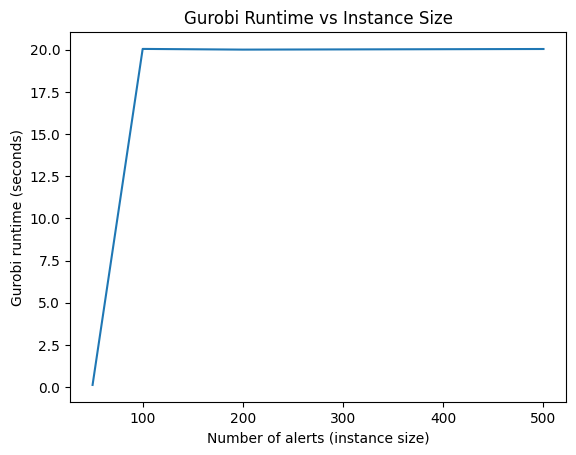

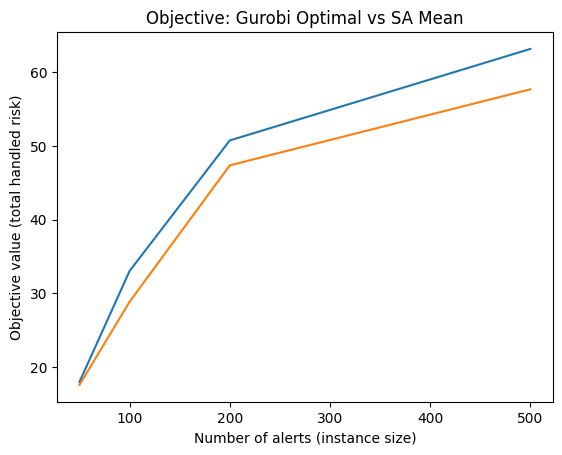

In [9]:
# 11.2 Plots: runtime and objective comparison

# Plot 1: Gurobi runtime vs instance size
plt.figure()
plt.plot(results_df["n_alerts"], results_df["gurobi_time_sec"])
plt.xlabel("Number of alerts (instance size)")
plt.ylabel("Gurobi runtime (seconds)")
plt.title("Gurobi Runtime vs Instance Size")
plt.show()

# Plot 2: Objective comparison (Gurobi vs SA mean)
plt.figure()
plt.plot(results_df["n_alerts"], results_df["gurobi_obj"])
plt.plot(results_df["n_alerts"], results_df["sa_mean"])
plt.xlabel("Number of alerts (instance size)")
plt.ylabel("Objective value (total handled risk)")
plt.title("Objective: Gurobi Optimal vs SA Mean")
plt.show()


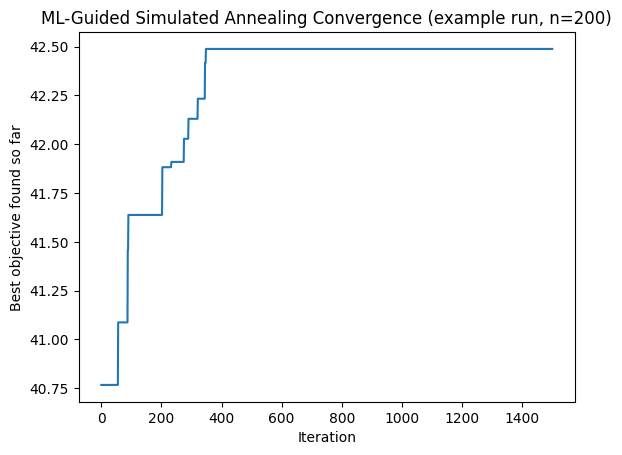

({'Risk_AUC': 0.8663101604278075,
  'Risk_Accuracy': 0.78,
  'Skill_Accuracy': 0.5,
  'Duration_MAE_Min': 4.413810964045872,
  'Duration_R2': 0.8152208906584305,
  'Mean_Predicted_Duration_Min': 17.24},
 42.48810708251223)

In [10]:
# 11.3 SA Convergence Example (one run)

n = 200
alerts_ex = generate_alerts(n, slots=8, critical_rate=0.02, seed=GLOBAL_SEED + 999)
alerts_ex, metrics_ex = train_ml_models_and_score(alerts_ex, seed=GLOBAL_SEED + 999)

_best_sched, best_val, curve = simulated_annealing(
    alerts_ex, analysts_df, avail_df, slots=8, iters=1500, T0=2.0, alpha=0.999, seed=GLOBAL_SEED + 12345
)

plt.figure()
plt.plot(curve)
plt.xlabel("Iteration")
plt.ylabel("Best objective found so far")
plt.title("ML-Guided Simulated Annealing Convergence (example run, n=200)")
plt.show()

metrics_ex, best_val

# 12. Results and Discussion

## 12.1 Solution Quality
- The table above compares the exact Gurobi objective with the mean, best, and worst SA objectives across 10 independent runs.
- Gurobi is the benchmark because it solves the MILP exactly and reports the optimal objective for the tested instance.
- SA is evaluated as an approximate method. The most important columns are `gap_mean_%` and `gap_best_%`: smaller values mean SA is closer to the exact optimum.
- Because SA is stochastic, the standard deviation column shows how stable the metaheuristic is across different random seeds. A small standard deviation means the algorithm repeatedly found similar-quality schedules.

## 12.2 Runtime / Scalability
- In these tested small-to-medium instances, Gurobi solved the MILP very quickly and produced optimal schedules. Therefore, for the current model size, Gurobi is the preferred method when an exact solver is available.
- SA runtime is controlled by the number of runs and iterations. In this notebook, SA is intentionally run 10 times with 1500 iterations to provide statistical evidence, so its reported runtime includes repeated stochastic experimentation.
- The practical value of SA is that it does not require a commercial exact solver and its runtime can be tuned directly. It may become more useful for larger, dynamic, nonlinear, or multi-shift SOC versions where exact solving becomes harder.

## 12.3 SOC Interpretation (What it means in real SOC terms)
The optimization prioritizes alerts with higher ML risk score and earlier deadlines while enforcing skill constraints (L1/L2/L3). The L3-on-call constraint adds realism: only critical confirmed incidents can be assigned to L3, and at most one such incident can be escalated during the shift. Break/availability constraints reduce capacity and represent realistic staffing limits.

## 12.4 Key Takeaway

- Gurobi is best for this current MILP when we need guaranteed optimal solutions and have access to the solver.
- Simulated Annealing (SA) is a useful metaheuristic alternative when we want a solver-independent, tunable approach that can be adapted to more complex future versions of the SOC triage problem.

## 12.5 Limitations
- Synthetic data is used because real SOC alert data is private and sensitive.
- Alerts are assumed to be known at the start of the shift, rather than arriving continuously.
- Each alert is modeled as consuming one time slot, although real alerts can require different investigation times.
- The current instance sizes are still manageable for Gurobi, so the scalability advantage of SA is better viewed as potential for future expanded models, not as proven faster in this exact experiment.

## 12.6 Future Work
- Multi-shift / multi-day staffing
- Online optimization for streaming alerts
- More detailed workload times (variable effort per alert)
- Stronger SA neighborhoods or hybrid methods combining greedy construction, local search, and exact repair steps


## 12.7 Trade-off Analysis: Gurobi vs ML-Guided Simulated Annealing

The advanced experiment is more realistic than the original one-alert-per-hour model because each alert has a predicted investigation duration in minutes and a predicted skill requirement.

- **Gurobi (Exact Method):**
  Solves the exact MILP under the predicted SOC conditions. It is best when the instance size and license limits allow the full model to be solved.

- **ML-Guided Simulated Annealing:**
  Produces feasible schedules using the same duration, skill, deadline, break, and L3 rules. It does not guarantee optimality, but it can still search effectively when the model becomes larger or harder.

- **AI/ML Value:**
  The ML models do not replace optimization. They estimate operational inputs first: risk, expected duration, and required skill. The optimizer then uses those predictions to decide which alerts should be handled by which analyst and in which hour.

- **Practical Insight:**
  This is closer to a real SOC workflow: alerts arrive with uncertain risk and uncertain workload, analysts have different skills, and short alerts can be grouped into the same analyst-hour instead of wasting a whole slot.

# 13. Conclusions

- We formulated SOC alert triage in a shift as a **MILP** and solved it with **Gurobi** for exact solutions.
- We implemented **Simulated Annealing** as a metaheuristic and evaluated it with multiple runs.
- The experimental study shows the trade-off between **optimality (Gurobi)** and **controlled compute time (SA)**.
- Bonus integration: **Logistic Regression risk scoring** provides a realistic data-driven objective.

Overall, the project demonstrates how optimization can improve SOC triage decisions under realistic operational constraints.


# 14. References

1. Kirkpatrick, S., Gelatt, C. D., & Vecchi, M. P. (1983). *Optimization by simulated annealing*. Science, 220(4598), 671–680.
2. Gurobi Optimization, LLC. *Gurobi Optimizer Reference Manual*.
3. Pinedo, M. L. (2016). *Scheduling: Theory, Algorithms, and Systems* (5th ed.). Springer.
4. Tariq, S., et al. (2025). *Alert Fatigue in Security Operations Centres*. ACM.